# Causal Forest — CATE summary and predictive evaluation

Loads the causal forest multi-output pipeline saved by `06_causal_forest_cate_estimation.ipynb`,
reports the per-endpoint CATE summary, and then evaluates how well the **optimised** forest
predicts the actual events:

- a **cross-validated ROC curve over the whole cohort** (out-of-fold, every patient scored by
  a model that never saw them), and
- a **confusion matrix on a held-out test set**.

Because a causal forest estimates the treatment *effect* θ(x) rather than an outcome
probability, the predicted **factual** risk is reconstructed from the DML identity
`P(Y=1 | x, T) = m(x) + (T − p_T)·θ(x)`, with `m(x)=E[Y|x]` the baseline outcome regression
and `p_T=P(T=1)` (≈0.5 by randomisation).

**Sign convention** (all endpoints are *adverse* events): `CATE < 0` → lDAPT lowers the
risk (**lDAPT better**); `CATE > 0` → **sDAPT better**.

In [1]:
import os
import sys
import glob

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.impute import KNNImputer
from sklearn.preprocessing import RobustScaler
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.metrics import roc_curve, roc_auc_score
from econml.dml import CausalForestDML
from lightgbm import LGBMRegressor, LGBMClassifier

from thesis_utils import plot_confusion_matrices

DATA_DIR = os.path.normpath(os.path.join(os.getcwd(), '..', '..', 'data'))
MODELS_DIR = os.path.normpath(os.path.join(os.getcwd(), '..', 'models'))

SAVE_DIR = os.path.join(MODELS_DIR, 'results')
os.makedirs(SAVE_DIR, exist_ok=True)

sns.set_theme(style='whitegrid', palette='muted')
pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', '{:.3f}'.format)

import warnings
warnings.filterwarnings('ignore')

NCOLS = 2

/home/tpioda/Bachelor-Thesis/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Load data and causal forest model

In [2]:
X = pd.read_parquet(os.path.join(DATA_DIR, 'X_features.parquet'))
y_df = pd.read_parquet(os.path.join(DATA_DIR, 'y_targets.parquet'))

TARGETS = [
    'cec_barc235_335d',
    'cec_cvdeath_335d',
    'cec_mi_335d',
    'cec_stroke_335d',
    'cec_bleed_335d',
]
TARGET_LABELS = ['barc_235', 'death', 'mi', 'stroke', 'bleed']
y_df = y_df[TARGETS]

X_num = X.select_dtypes(include=[np.number])

# Treatment assignment (1 = prolonged DAPT, 0 = abbreviated DAPT) for the
# factual-prediction reconstruction in the evaluation below.
T = X['regimen'].map({'prolonged DAPT': 1, 'abbreviated DAPT': 0}).to_numpy()

SAVE_DIR = os.path.join(MODELS_DIR, 'CausalForest')

# Which flexibility level to analyse — one of the presets fit in 06:
#   'regularized' | 'medium' | 'flexible', or None for the canonical default
#   (CausalForest_multioutput.joblib, which 06 mirrors from DEFAULT_LEVEL='medium').
# Change this and re-run the notebook to visualise a different base model.
MODEL_LEVEL = 'flexible'

fname = (f'CausalForest_multioutput_{MODEL_LEVEL}.joblib'
         if MODEL_LEVEL else 'CausalForest_multioutput.joblib')
model_path = os.path.join(SAVE_DIR, fname)
if not os.path.exists(model_path):
    available = sorted(os.path.basename(p)
                       for p in glob.glob(os.path.join(SAVE_DIR, 'CausalForest_*.joblib')))
    raise FileNotFoundError(
        f'{fname} not found in {SAVE_DIR} (available: {available}); '
        'run 06_causal_forest_cate_estimation.ipynb first.')

from casual_multioutput_pipeline import CausalMultiOutputPipeline

pipeline = joblib.load(model_path)
model_name = os.path.basename(model_path)
print(f'Model: {model_name}  (level={MODEL_LEVEL or "default"})')
print(f'Patients: {len(X_num)}, features: {X_num.shape[1]}')

Model: CausalForest_multioutput_flexible.joblib  (level=flexible)
Patients: 4579, features: 63


## Estimate CATE on the full cohort

Generate causal effect predictions for every patient and every endpoint.

In [3]:
cate_preds = pipeline.predict_cate(X_num.values)
cate = pd.DataFrame(cate_preds, columns=TARGET_LABELS, index=X_num.index)

summary = pd.DataFrame({
    'mean_CATE': cate.mean(),
    'std_CATE': cate.std(),
    'pct_lDAPT_better': (cate < 0).mean() * 100,
    'pct_sDAPT_better': (cate > 0).mean() * 100,
})
print('CATE summary (Causal Forest)')
print(summary.round(4))

CATE summary (Causal Forest)
          mean_CATE  std_CATE  pct_lDAPT_better  pct_sDAPT_better
barc_235      0.026     0.014             2.883            97.117
death         0.004     0.011            27.801            72.199
mi           -0.005     0.012            76.392            23.608
stroke        0.004     0.006            12.208            87.792
bleed         0.045     0.016             0.764            99.236


## Visualisations

### CATE distributions per target

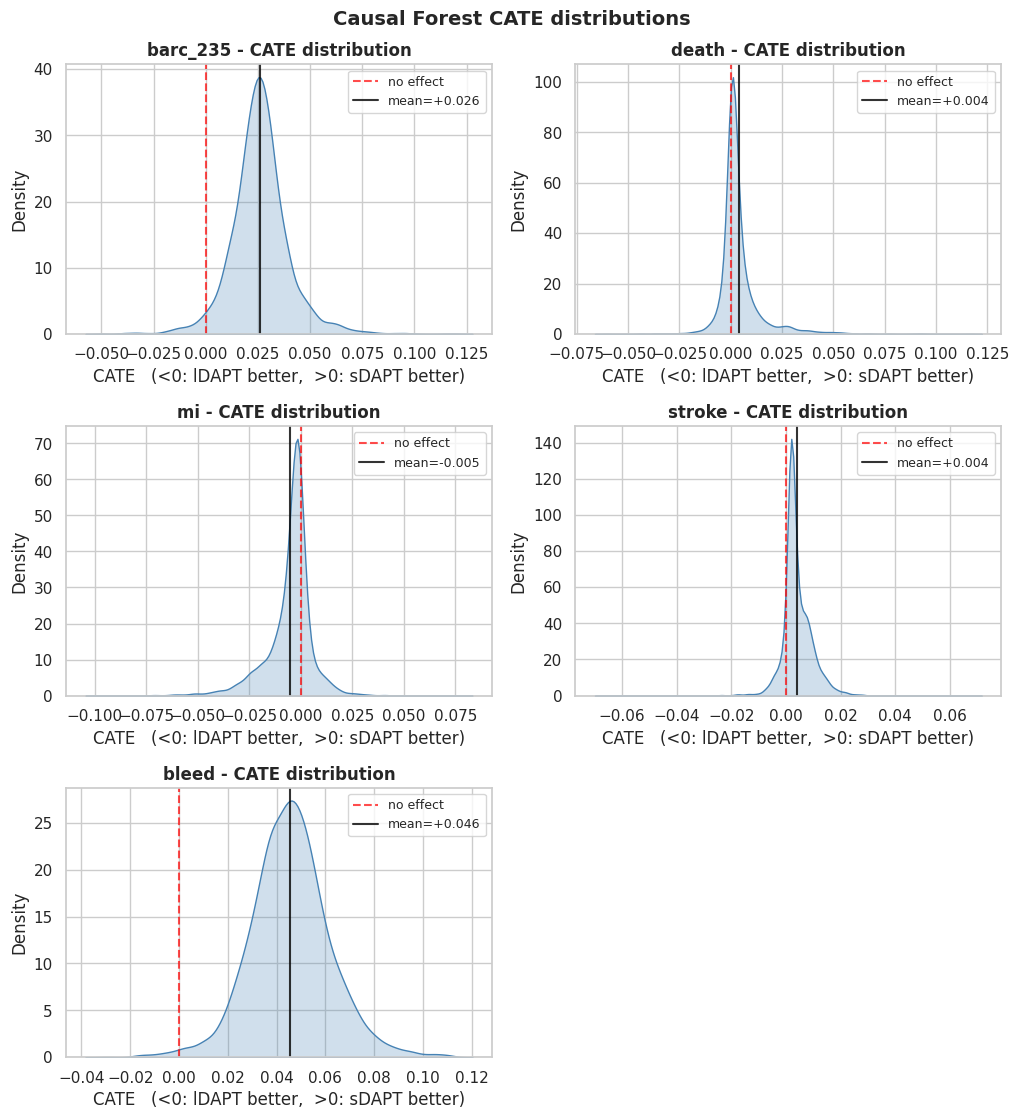

In [4]:
def target_grid(ncols=2, figsize_per=(5.2, 3.8)):
    n = len(TARGET_LABELS)
    nrows = int(np.ceil(n / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(figsize_per[0] * ncols, figsize_per[1] * nrows), squeeze=False)
    axes = axes.ravel()
    for ax in axes[n:]:
        ax.set_visible(False)
    return fig, axes

fig, axes = target_grid(ncols=2)
for ax, label in zip(axes, TARGET_LABELS):
    sns.kdeplot(cate[label], ax=ax, fill=True, color='steelblue')
    ax.axvline(0, color='red', linestyle='--', alpha=0.7, label='no effect')
    ax.axvline(cate[label].mean(), color='black', linestyle='-', alpha=0.8,
               label=f'mean={cate[label].mean():+.3f}')
    ax.set_title(f'{label} - CATE distribution', fontweight='bold')
    ax.set_xlabel('CATE   (<0: lDAPT better,  >0: sDAPT better)')
    ax.legend(fontsize=9)
fig.suptitle('Causal Forest CATE distributions', fontsize=14, fontweight='bold')
plt.tight_layout()

plt.show()

### Sorted CATE (uplift curves)

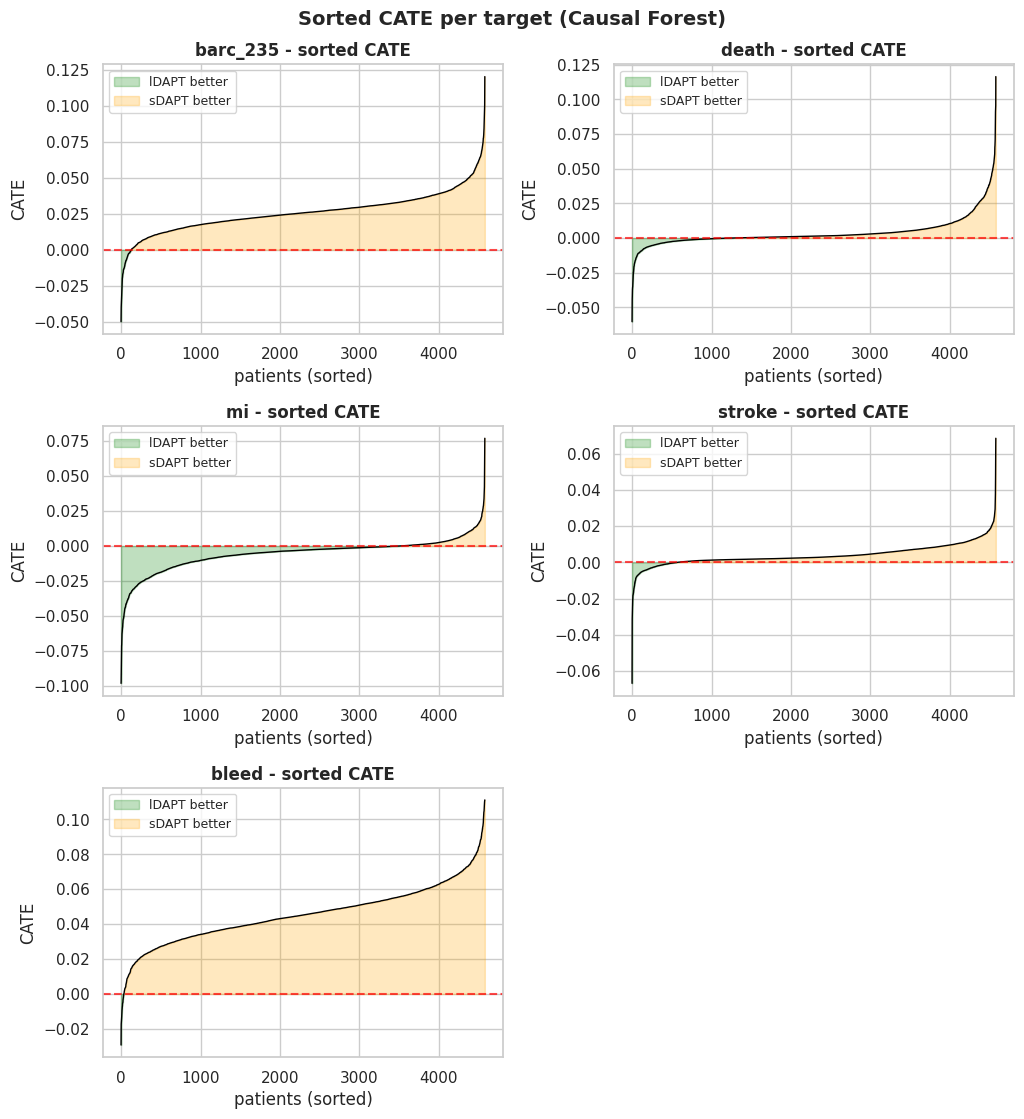

In [5]:
fig, axes = target_grid(ncols=2)
for ax, label in zip(axes, TARGET_LABELS):
    ordered = np.sort(cate[label].to_numpy())
    xs = np.arange(len(ordered))
    ax.plot(xs, ordered, linewidth=1.0, color='black')
    ax.axhline(0, color='red', linestyle='--', alpha=0.7)
    ax.fill_between(xs, ordered, 0, where=ordered < 0, color='green', alpha=0.25, label='lDAPT better')
    ax.fill_between(xs, ordered, 0, where=ordered > 0, color='orange', alpha=0.25, label='sDAPT better')
    ax.set_title(f'{label} - sorted CATE', fontweight='bold')
    ax.set_xlabel('patients (sorted)')
    ax.set_ylabel('CATE')
    ax.legend(fontsize=9, loc='upper left')
fig.suptitle('Sorted CATE per target (Causal Forest)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(
    os.path.join(SAVE_DIR, f'SORTED_CATE','sorted_cate{MODEL_LEVEL}.png'),
    dpi=300,
    bbox_inches='tight',
)
plt.show()

## Is the heterogeneity real? — RATE / BLP / calibration

The CATE summary above always *looks* like heterogeneity, but with rare endpoints and a
moderate sample most of that spread can be noise around a roughly constant effect. Before
interpreting *who* benefits (feature importance, sub-group effects), this section tests
whether ranking patients by predicted effect tracks **real** treatment-effect differences,
using doubly-robust validation on a held-out split — `econml.validate.DRTester`, the Python
analogue of grf's `rank_average_treatment_effect` + `best_linear_projection` +
`test_calibration`:

- **BLP slope** — regression of the doubly-robust effect score on the predicted CATE.
  Significantly positive ⇒ the forest captures real signal; ≈ 0 ⇒ no usable heterogeneity.
- **RATE (AUTOC)** and **QINI** — area under the curve obtained by treating the
  highest-CATE patients first. Positive and significant ⇒ targeting by CATE beats random.
- **Calibration R²** — agreement between predicted and realised group effects.

Treatment is randomised, so the propensity is the *known* constant assignment probability
(`DummyClassifier(strategy='prior')`) rather than an estimated model — the recommended
choice for the causal forest's orthogonal moment under an RCT.

> ⚠️ Compute-heavy: refits the optimised forest once per endpoint on a 70% split.


In [6]:
from econml.validate import DRTester
from sklearn.dummy import DummyClassifier

# Optimised forest hyper-parameters from the saved pipeline (drop the inference flag).
CF_PARAMS = {k: v for k, v in pipeline.cf_params.items() if k != 'inference'}
KNN_NEIGHBORS = getattr(pipeline, 'knn_neighbors', 5)
Xv, Yv = X_num.values, y_df.values.astype(int)

# Honest split: refit each forest on 70% and validate on patients it never saw.
tr_idx, va_idx = train_test_split(
    np.arange(len(Xv)), test_size=0.3, random_state=42, stratify=T)
imp = KNNImputer(n_neighbors=KNN_NEIGHBORS).fit(Xv[tr_idx])
sc = RobustScaler().fit(imp.transform(Xv[tr_idx]))
Xtr_s = sc.transform(imp.transform(Xv[tr_idx]))
Xva_s = sc.transform(imp.transform(Xv[va_idx]))

het_results, rows = {}, []
for i, label in enumerate(TARGET_LABELS):
    # Nuisance learners reuse the saved pipeline's configuration (single source
    # of truth, identical to the model fit in 06); the forest is still refit on
    # the 70% split so validation stays leakage-free.
    cf = CausalForestDML(
        model_y=pipeline.make_model_y(),
        model_t=pipeline.make_model_t(),
        discrete_treatment=True, cv=3, honest=True, inference=False,
        random_state=42, **CF_PARAMS,
    ).fit(Yv[tr_idx, i], T[tr_idx], X=Xtr_s, W=None)

    # A heavily regularised forest can collapse to an (almost) constant CATE — i.e.
    # no detected heterogeneity. DRTester's BLP then regresses the doubly-robust
    # score on a constant predictor, which statsmodels can't fit (add_constant drops
    # the duplicate intercept) and evaluate_all raises an IndexError. Record the
    # degenerate "no heterogeneity" result instead of crashing the comparison — for
    # the regularized preset a flat CATE is the *expected* outcome, not a failure.
    if np.ptp(cf.effect(Xva_s)) < 1e-9:
        het_results[label] = None
        rows.append({
            'endpoint': label,
            'BLP_slope': np.nan, 'BLP_p': np.nan,
            'RATE_AUTOC': np.nan, 'AUTOC_p': np.nan,
            'QINI': np.nan, 'QINI_p': np.nan,
            'cal_R2': np.nan,
        })
        print(f'[{label}] constant CATE — no heterogeneity to validate (skipped)')
        continue

    # Doubly-robust validation. Treatment is randomised, so the propensity is the
    # known constant assignment probability rather than an estimated model.
    tester = DRTester(
        model_regression=pipeline.make_model_y(),
        model_propensity=DummyClassifier(strategy='prior'),
        cate=cf, cv=3,
    )
    tester.fit_nuisance(Xva_s, T[va_idx], Yv[va_idx, i], Xtr_s, T[tr_idx], Yv[tr_idx, i])
    het_results[label] = tester.evaluate_all(Xva_s, Xtr_s)
    s = het_results[label].summary().iloc[0]
    rows.append({
        'endpoint': label,
        'BLP_slope': s['blp_est'], 'BLP_p': s['blp_pval'],
        'RATE_AUTOC': s['autoc_est'], 'AUTOC_p': s['autoc_pval'],
        'QINI': s['qini_est'], 'QINI_p': s['qini_pval'],
        'cal_R2': s['cal_r_squared'],
    })

het = pd.DataFrame(rows).set_index('endpoint')
print('Heterogeneity validation on held-out 30% '
      '(positive estimate with small p ==> real, usable heterogeneity)')
print(het.round(3))

Heterogeneity validation on held-out 30% (positive estimate with small p ==> real, usable heterogeneity)
          BLP_slope  BLP_p  RATE_AUTOC  AUTOC_p   QINI  QINI_p  cal_R2
endpoint                                                              
barc_235      1.420  0.243       0.015    0.115  0.004   0.151  -0.371
death         1.919  0.016       0.008    0.117  0.001   0.322  -0.459
mi            1.731  0.050       0.001    0.430  0.003   0.097   0.301
stroke       -0.138  0.843      -0.002    0.343 -0.001   0.210  -0.904
bleed        -0.188  0.875       0.001    0.482 -0.002   0.358  -0.384


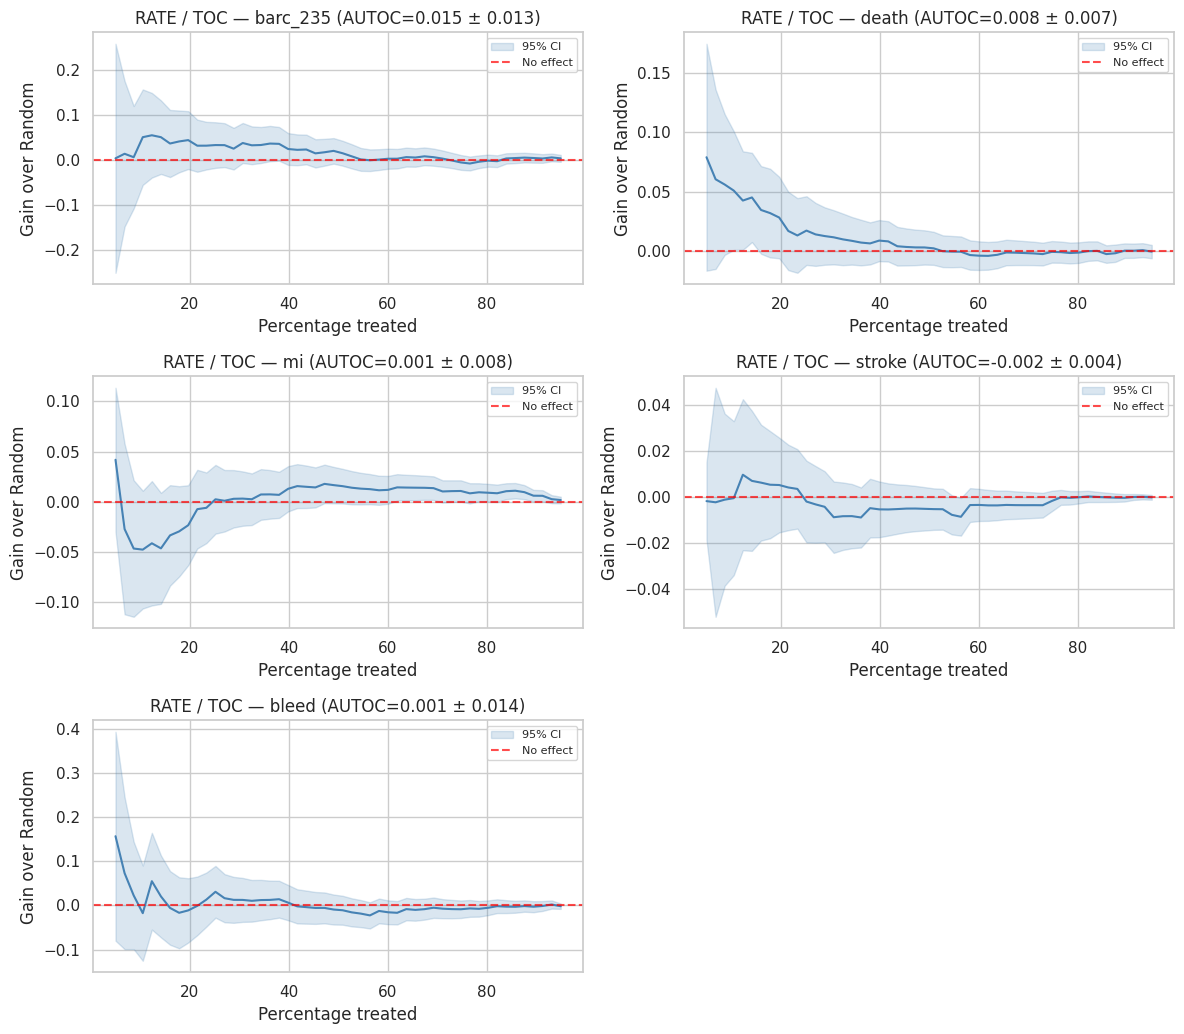

In [7]:
# RATE / TOC curve per endpoint: average effect among the top-ranked patients as we
# treat from the highest predicted CATE downward. A curve sitting above zero means
# prioritising by predicted effect beats random targeting. econml's plot_toc draws
# its own figure, so the curve data is read off the results and drawn into a shared
# subplot grid instead.
NROWS = int(np.ceil(len(TARGET_LABELS) / NCOLS))
fig, axes = plt.subplots(NROWS, NCOLS, figsize=(6 * NCOLS, 3.5 * NROWS))
axes = axes.ravel() 

for i, label in enumerate(TARGET_LABELS):
    ax = axes[i]
    res = het_results[label]
    if res is None:               # constant CATE: no ranking, nothing to plot
        ax.text(0.5, 0.5, f'{label}\nconstant CATE\n(no heterogeneity)',
                ha='center', va='center', transform=ax.transAxes, fontsize=10)
        ax.set(title=f'RATE / TOC — {label}',
               xlabel='Percentage treated', ylabel='Gain over Random')
        continue
    toc = res.toc
    df = toc.curves[1]            # treatment = 1 (lDAPT)
    s = toc.summary().iloc[0]     # AUTOC integral + standard error
    x = df['Percentage treated']
    band = 1.96 * df['err']
    ax.plot(x, df['value'], color='steelblue')
    ax.fill_between(x, df['value'] - band, df['value'] + band,
                    color='steelblue', alpha=0.2, label='95% CI')
    ax.axhline(0, color='red', linestyle='--', alpha=0.7, label='No effect')
    ax.set(title=f"RATE / TOC — {label} (AUTOC={s['est']:.3f} ± {s['se']:.3f})",
           xlabel='Percentage treated', ylabel='Gain over Random')
    ax.legend(fontsize=8)

for ax in axes[len(TARGET_LABELS):]:
    ax.set_visible(False)

plt.tight_layout()
plt.savefig(
    os.path.join(SAVE_DIR, f'RATE_TOC','rate_toc_{MODEL_LEVEL}.png'),
    dpi=300,
    bbox_inches='tight',
)
plt.show()

## Predictive evaluation — out-of-fold CV ROC (factual outcome)

A causal forest outputs the treatment effect θ(x), not P(event), so it has no native ROC.
To judge how well it predicts the **actual** events, each patient's factual risk is
reconstructed from the DML identity (treatment is randomised, so `E[T|x] = p_T` is constant):

`P(Y=1 | x_i, T_i) = m(x_i) + (T_i − p_T)·θ(x_i)`

where `m(x)=E[Y|x]` is the baseline outcome regression (the same LGBM config the forest uses
internally) and `θ(x)` comes from the **optimised** forest (its tuned hyper-parameters are
read from the saved pipeline's `cf_params`). The optimised configuration is refit
**out-of-fold** (5-fold `StratifiedKFold` per target), so every patient is scored by a model
that never saw them — the same leakage-free protocol used for the other models in this project.

> ⚠️ Compute-heavy: this refits the optimised forest 5 folds × 5 targets. Inference
> (confidence intervals) is disabled here since only point effects are needed.

In [8]:
# Optimised forest hyper-parameters baked into the saved pipeline; drop the
# inference flag (only point effects are needed here, which is much faster).
CF_PARAMS = {k: v for k, v in pipeline.cf_params.items() if k != 'inference'}
KNN_NEIGHBORS = getattr(pipeline, 'knn_neighbors', 5)
P_T = float(T.mean())   # P(T=1): ~0.5 by randomisation


def fit_predict_factual(X_tr, y_tr, T_tr, X_te, T_te):
    # Factual P(Y=1) on X_te for one binary target: baseline outcome regression
    # m(x)=E[Y|x] plus the optimised forest's effect, read off at the patient's
    # actual treatment. The baseline and the forest's nuisances reuse the saved
    # pipeline's learner configuration (make_model_y/make_model_t), refit here on
    # the training part only so every prediction stays out-of-fold.
    imp = KNNImputer(n_neighbors=KNN_NEIGHBORS).fit(X_tr)
    sc = RobustScaler().fit(imp.transform(X_tr))
    X_tr_s = sc.transform(imp.transform(X_tr))
    X_te_s = sc.transform(imp.transform(X_te))
    m_hat = pipeline.make_model_y().fit(X_tr_s, y_tr)
    cf = CausalForestDML(
        model_y=pipeline.make_model_y(),
        model_t=pipeline.make_model_t(),
        discrete_treatment=True, cv=3, honest=True, inference=False,
        random_state=42, **CF_PARAMS,
    )
    cf.fit(y_tr, T_tr, X=X_tr_s, W=None)
    y_hat = m_hat.predict(X_te_s) + (T_te - P_T) * cf.effect(X_te_s)
    return np.clip(y_hat, 0.0, 1.0)


Xv = X_num.values
Yv = y_df.values.astype(int)
n, k = Xv.shape[0], Yv.shape[1]

# Out-of-fold factual probabilities over the whole cohort, one column per target.
oof = np.zeros((n, k))
for i, label in enumerate(TARGET_LABELS):
    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    for tr, va in skf.split(Xv, Yv[:, i]):
        oof[va, i] = fit_predict_factual(Xv[tr], Yv[tr, i], T[tr], Xv[va], T[va])
    print(f'[{label}] out-of-fold AUROC = {roc_auc_score(Yv[:, i], oof[:, i]):.3f}')

# Pooled out-of-fold ROC curve per target.
fig, ax = plt.subplots(figsize=(7, 6))
colors = plt.cm.tab10(np.linspace(0, 1, k))
for i, label in enumerate(TARGET_LABELS):
    fpr, tpr, _ = roc_curve(Yv[:, i], oof[:, i])
    ax.plot(fpr, tpr, color=colors[i],
            label=f'{label} (AUROC={roc_auc_score(Yv[:, i], oof[:, i]):.3f})')
ax.plot([0, 1], [0, 1], 'k--', alpha=0.6, label='chance')
ax.set(xlabel='False positive rate', ylabel='True positive rate',
       xlim=(0, 1), ylim=(0, 1.02),
       title='Causal Forest — out-of-fold CV ROC (factual outcome)')
ax.legend(fontsize=9, loc='lower right')
plt.tight_layout()
plt.savefig(
    os.path.join(SAVE_DIR, f'ROC_', f'roc_{MODEL_LEVEL}.png'),
    dpi=150,
    bbox_inches='tight',
)
plt.show()

[barc_235] out-of-fold AUROC = 0.584
[death] out-of-fold AUROC = 0.619
[mi] out-of-fold AUROC = 0.633
[stroke] out-of-fold AUROC = 0.583


KeyboardInterrupt: 

## Confusion matrices on a held-out test set

A single 80/20 split (stratified by treatment arm) is held out; the optimised configuration
is refit on the train part only and the reconstructed factual predictions are thresholded so
the predicted positive rate tracks each endpoint's training event rate — the same event-rate
rule used elsewhere in the project, since these averaged risks rarely cross the default 0.5
cutoff for such rare events.

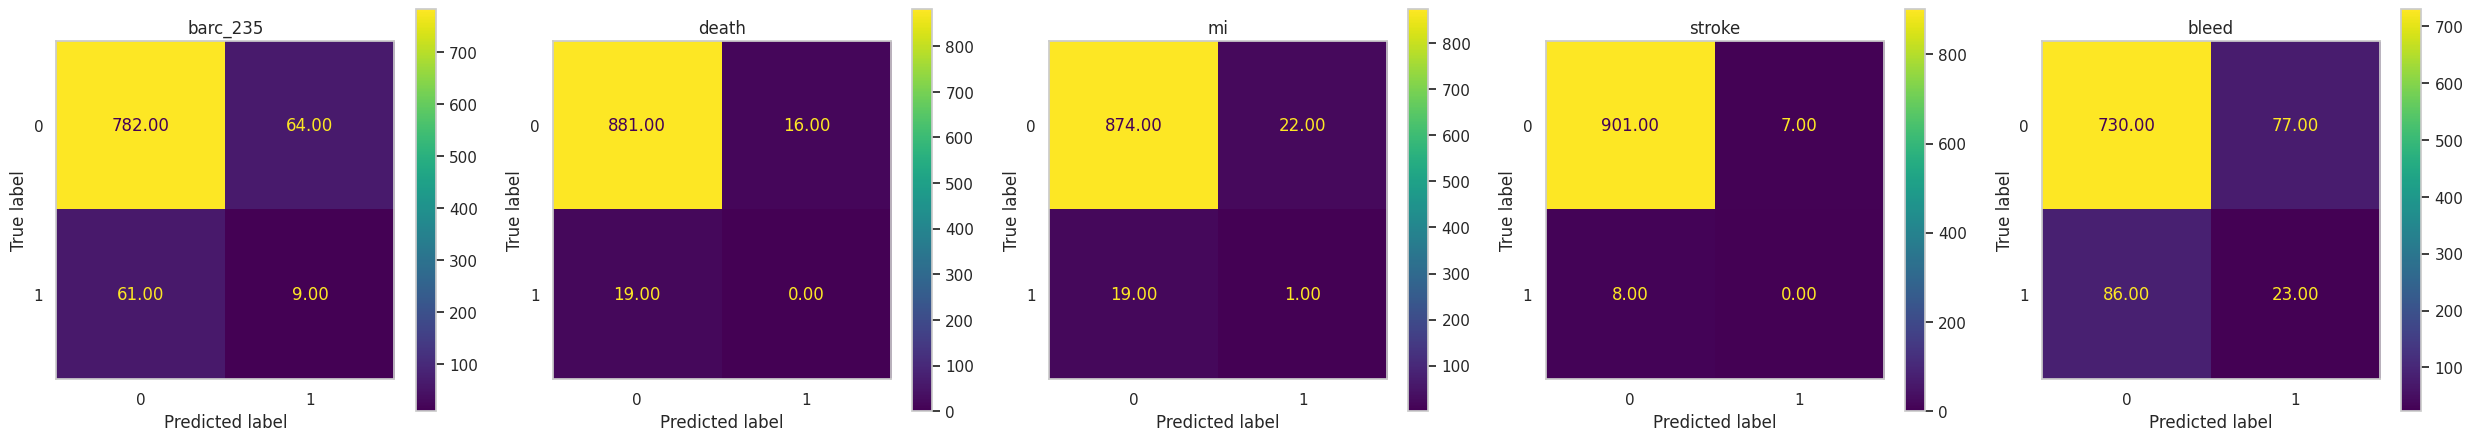

In [ ]:
X_tr, X_te, y_tr, y_te, T_tr, T_te = train_test_split(
    Xv, Yv, T, test_size=0.2, random_state=42, stratify=T)

# Refit the optimised configuration on the train split and reconstruct factual
# risks on the held-out test patients, one column per target.
proba_te = np.column_stack([
    fit_predict_factual(X_tr, y_tr[:, i], T_tr, X_te, T_te)
    for i in range(k)
])

# Per-target threshold = (1 - train event rate) quantile of the predicted test
# probabilities, so the predicted positive fraction tracks the event rate
# (these averaged risks rarely cross 0.5 for the rare endpoints).
rates = y_tr.mean(axis=0)
thresholds = np.array([np.quantile(proba_te[:, i], 1.0 - rates[i]) for i in range(k)])
y_pred = (proba_te >= thresholds).astype(int)

plot_confusion_matrices(
    pd.DataFrame(y_te, columns=TARGET_LABELS), y_pred,
    titles=TARGET_LABELS, normalize=False,
)

## Causal Feature Importance

Mean feature importance across all endpoints, from causal forest variable importance.

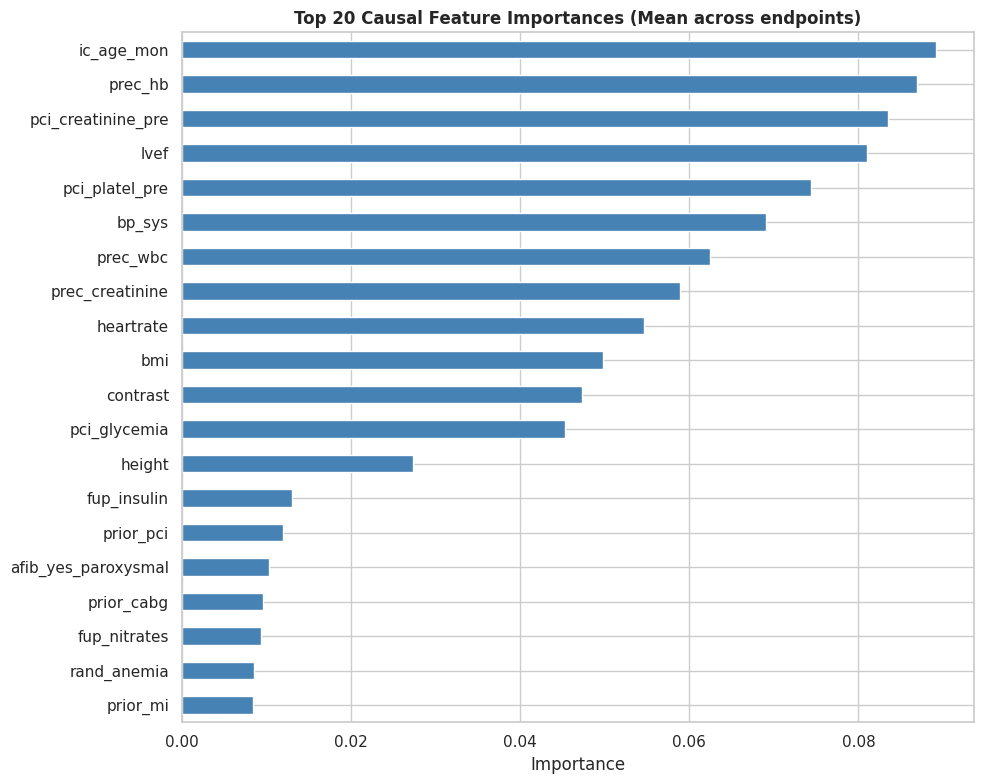

In [ ]:
feat_importances = pd.Series(
    pipeline.get_feature_importances(),
    index=X.drop(['regimen'], axis=1).columns,
)

fig, ax = plt.subplots(figsize=(10, 8))
feat_importances.nlargest(20).sort_values().plot(kind='barh', ax=ax, color='steelblue')
ax.set_title('Top 20 Causal Feature Importances (Mean across endpoints)', fontweight='bold')
ax.set_xlabel('Importance')
plt.tight_layout()
plt.show()